In [1]:
import glob
import re
import numpy as np
import pandas as pd

#files = glob.glob("../results_zcum_*_zLIM*.txt")
files = glob.glob("../profile_zcum_*_zLIM*_*.txt")
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline as cs
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])
import json
from matplotlib import ticker
plt.rcParams['font.family'] = 'serif'


In [3]:
C1_CMB=pd.read_csv('C1_CMB_REVB_errors.csv',index_col=0)

C1_LG=pd.read_csv('C1_LG_REVB_errors.csv',index_col=0)
C1_HD=pd.read_csv('C1_HD_REVB_errors.csv',index_col=0)

C1_HEL=pd.read_csv('C1_HEL_REVB_errors.csv',index_col=0)




C1_CMB['QD_errors'] = C1_CMB['QD_errors'].apply(json.loads)
C1_CMB['QM_errors'] = C1_CMB['QM_errors'].apply(json.loads)

C1_HEL['QD_errors'] = C1_HEL['QD_errors'].apply(json.loads)
C1_HEL['QM_errors'] = C1_HEL['QM_errors'].apply(json.loads)

C1_LG['QD_errors'] = C1_LG['QD_errors'].apply(json.loads)
C1_LG['QM_errors'] = C1_LG['QM_errors'].apply(json.loads)


C1_HD['QD_errors'] = C1_HD['QD_errors'].apply(json.loads)
C1_HD['QM_errors'] = C1_HD['QM_errors'].apply(json.loads)

HD_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_0_results.txt', delim_whitespace=True)
HEL_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_7_results.txt', delim_whitespace=True)
CMB_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_8_results.txt', delim_whitespace=True)
LG_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_9_results.txt', delim_whitespace=True)



/tmp/ipykernel_46165/39782682.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  HD_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_0_results.txt', delim_whitespace=True)
/tmp/ipykernel_46165/39782682.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  HEL_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_7_results.txt', delim_whitespace=True)
/tmp/ipykernel_46165/39782682.py:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  CMB_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_8_results.txt', delim_whitespace=True)
/tmp/ipykernel_46165/39782682.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is dep

In [8]:
def error_bars(df_col):
    errors=np.reshape(np.array(list(df_col)).T,(2,15))
    return errors

In [ ]:
df_error_cmb_age = pd.read_csv('CMB_QM_errors_C1_age_bias.csv')
df_error_hel_age = pd.read_csv('HEL_QM_errors_C1_age_bias.csv')
df_error_hd_age = pd.read_csv('HD_QM_errors_C1_age_bias.csv')
df_error_lg_age = pd.read_csv('LG_QM_errors_C1_age_bias.csv')


,zlim,QM,root
0,0.00587,-0.015909,"[-0.09659292935552227, 0.0642431088772685]"
1,0.00907,-0.057047,"[-0.13881576636063514, 0.02415865145630291]"
2,0.01351,-0.041175,"[-0.12123792763317531, 0.03830597154631475]"
3,0.01613,-0.026021,"[-0.10656073370760835, 0.05391774439622643]"
4,0.01826,-0.022723,"[-0.10351795801686488, 0.05743212866291661]"
5,0.02121,-0.042626,"[-0.12466547042229767, 0.03876991556251925]"
6,0.02324,-0.028960,"[-0.1124035458227203, 0.0538280611994802]"
7,0.02531,-0.049324,"[-0.13554923856218434, 0.03622251854124649]"
8,0.02873,-0.045202,"[-0.13463674562427252, 0.04296497348651157]"
9,0.03139,-0.056446,"[-0.1551468091995476, 0.03734564769936863]"


In [10]:
yerr_low

[np.float64(0.08068353145552228),
 np.float64(0.08176840236063514),
 np.float64(0.0800625181331753),
 np.float64(0.08053940240760835),
 np.float64(0.08079469721686489),
 np.float64(0.08203932722229768),
 np.float64(0.0834435925227203),
 np.float64(0.08622560826218434),
 np.float64(0.08943514062427252),
 np.float64(0.09870116899954759),
 np.float64(0.0986400789797699),
 np.float64(0.10331277265142477),
 np.float64(0.11580361798323913),
 np.float64(0.1372534155193647),
 np.float64(0.16484257120094123)]

/tmp/ipykernel_46165/3944872941.py:43: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(np.array(eval(f'C1_{ar[idx]}')['zlim']), np.array(eval(f'C1_{ar[idx]}')['qm']),marker='o',markersize=7.5,mfc='w', yerr=error_bars(eval(f'C1_{ar[idx]}')['QM_errors']),color ='r', fmt='o', capsize=5,label='No age bias corrections',lw=3)
/tmp/ipykernel_46165/3944872941.py:43: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(np.array(eval(f'C1_{ar[idx]}')['zlim']), np.array(eval(f'C1_{ar[idx]}')['qm']),marker='o',markersize=7.5,mfc='w', yerr=error_bars(eval(f'C1_{ar[idx]}')['QM_errors']),color ='r', fmt='o', capsize=5,label='No age bias corrections',lw=3)
/tmp/ipykernel_46165/3944872941.py:43: UserWarning: marker is redundantly defined by the 'marker' keyword 

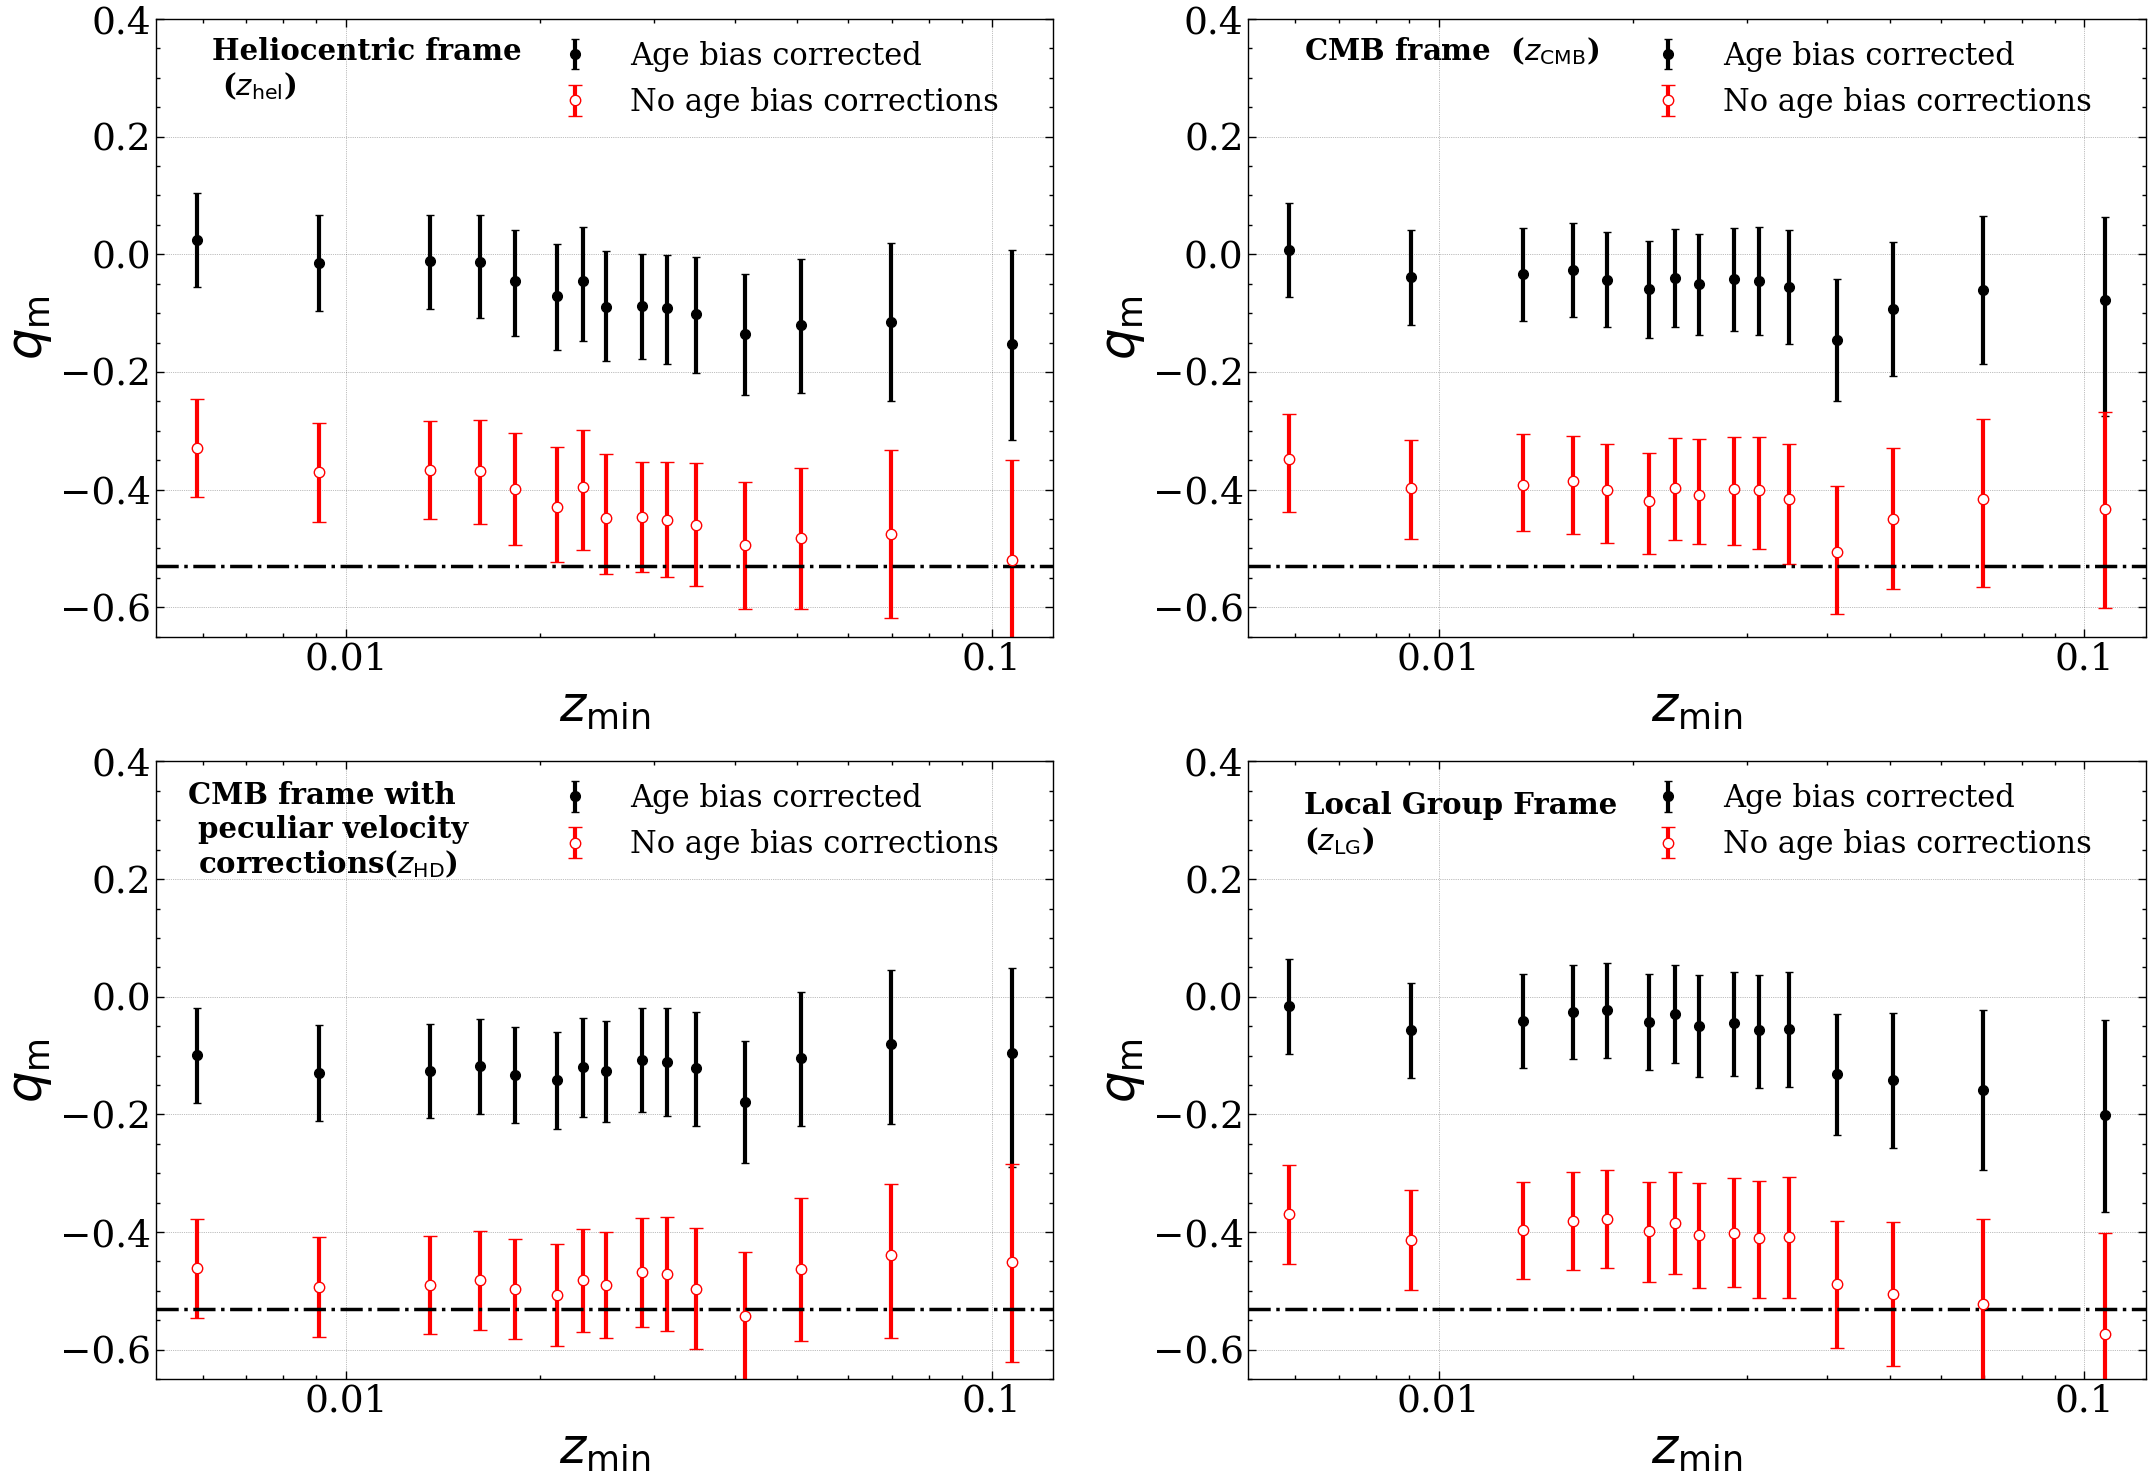

In [14]:
ar = ['HEL', 'CMB','HD', 'LG']
fig, axes = plt.subplots(2, 2, figsize=(22, 15))
axes = axes.flatten()
xloc=0.0052
labels=['Heliocentric frame \n ($z_{\mathrm{hel}}$)', 'CMB frame  ($z_{\mathrm{CMB}}$)' , 'CMB frame with \n peculiar velocity \n corrections($z_{\mathrm{HD}}$)','Local Group Frame \n($z_{\mathrm{LG}}$)']

# loc=[[xloc,0.15],[xloc,0.15],[xloc,0.1],[xloc,0.12]]
loc=[[xloc+0.001,0.27],[xloc+0.001,0.33],[xloc+0.0005,0.21],[xloc+0.001,0.25]]
for idx, a in enumerate(ar):
    ax = axes[idx]
    df_min = pd.read_csv(f"errors_profile_z{a}.txt", sep=',')
    df_min_age = globals()[f"df_error_{a.lower()}_age"]
    zlims = df_min['zLIM'].values
    qm_best = df_min['QM'].values
    qm_best_age = df_min_age['QM'].values
    
    yerr_low = []
    yerr_high = []
    
    for i, roots_str in enumerate(df_min_age['root']):
        roots = eval(roots_str)
        roots = np.array(roots)
        q_best = qm_best_age[i]
        
        left_roots = roots[roots < q_best]
        right_roots = roots[roots > q_best]
        
        if len(left_roots) > 0:
            err_low = q_best - left_roots.max()
        else:
            err_low = 0
            
        if len(right_roots) > 0:
            err_high = right_roots.min() - q_best
        else:
            err_high = 0
            
        yerr_low.append(err_low)
        yerr_high.append(err_high)
    
    ax.errorbar(zlims, qm_best_age, yerr=[yerr_low, yerr_high], 
                fmt='o', label=f'Age bias corrected', capsize=3, markersize=7,color='k',lw=3)
    ax.errorbar(np.array(eval(f'C1_{ar[idx]}')['zlim']), np.array(eval(f'C1_{ar[idx]}')['qm']),marker='o',markersize=7.5,mfc='w', yerr=error_bars(eval(f'C1_{ar[idx]}')['QM_errors']),color ='r', fmt='o', capsize=5,label='No age bias corrections',lw=3)

    ax.axhline(-0.53,ls='-.',color='k',lw=2.5)
    ax.set_xscale('log')
    ax.tick_params(axis='x', labelsize=27)
    ax.tick_params(axis='y', labelsize=27)
    
    ax.legend(fontsize=22,loc=(0.42,0.82),frameon=False)
    ax.grid(ls=':')
    ax.set_xlabel('$z_{\mathrm{min}}$',size=36)
    ax.set_ylabel('$q_{\mathrm{m}}$',size=36)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,pos: (float(x))))
    #plt.text(*loc[idx],labels[idx],weight='bold',fontsize=20)
    #ax.set_ylabel("$q_m$")
    #ax.legend()
    #ax.grid(True, alpha=0.3)
    #ax.set_xscale('log')
    ax.set_ylim(-0.65,0.4)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,pos: (float(x))))
    ax.text(*loc[idx],labels[idx],weight='bold',fontsize=21)
    #ax.set_title(f'z{a}')

plt.tight_layout()

plt.savefig('all_frames_qm_0.53_age_bias_v2.pdf',dpi=300)
plt.show()